In [25]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [26]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [60]:
class CricketState(TypedDict):
    Runs: int
    Balls: int
    Sixes: int
    Fours: int
    Strike_rate: float
    Balls_per_boundary: float
    boundary_percentage: float
    summary: str

In [61]:
def calculate_strike_rate(state: CricketState) -> CricketState:
    StrikeRate = (state["Runs"] / state["Balls"]) * 100 if state["Balls"] > 0 else 0.0
    state["Strike_rate"] = StrikeRate
    return {"Strike_rate": StrikeRate}

def calculate_balls_per_boundary(state: CricketState) -> CricketState:
    total_boundaries = state["Sixes"] + state["Fours"]
    state["BallsPerBoundary"] = state["Balls"] / total_boundaries if total_boundaries > 0 else float('inf')
    return {"Balls_Per_Boundary": BallsPerBoundary}

def calculate_boundary_percentage(state: CricketState) -> CricketState:
    total_boundaries = state["Sixes"] + state["Fours"]
    state["BoundaryPercentage"] = (total_boundaries / state["Balls"]) * 100 if state["Balls"] > 0 else 0.0
    return {"BoundaryPercentage": BoundaryPercentage}

def summarize_performance(state: CricketState) -> CricketState:
    summary = (
        f"Runs: {state['Runs']}, Balls: {state['Balls']}, Sixes: {state['Sixes']}, "
        f"Fours: {state['Fours']}, Strike Rate: {state['Strike_rate']:.2f}%, "
        f"Balls per Boundary: {state['BallsPerBoundary']:.2f}, "
        f"Boundary Percentage: {state['BoundaryPercentage']:.2f}%"
    )
    return {"Summary": summary}

In [62]:
# Returning state allows the graph to reach END

graph = StateGraph(CricketState)

# 2. Register all 4 nodes
graph.add_node("Calculate Strike Rate", calculate_strike_rate)
graph.add_node("Calculate Balls per Boundary", calculate_balls_per_boundary)
graph.add_node("Calculate Boundary Percentage", calculate_boundary_percentage)
graph.add_node("summarize_performance", summarize_performance) # MUST be added here

# 3. Parallel Fan-out from START
graph.add_edge(START, "Calculate Strike Rate")
graph.add_edge(START, "Calculate Balls per Boundary")
graph.add_edge(START, "Calculate Boundary Percentage")

# 4. Fan-in to the summary node
# Use the string "summarize_performance" as the destination
graph.add_edge("Calculate Strike Rate", "summarize_performance")
graph.add_edge("Calculate Balls per Boundary", "summarize_performance")
graph.add_edge("Calculate Boundary Percentage", "summarize_performance")

# 5. Final edge to END
graph.add_edge("summarize_performance", END)

work_flow = graph.compile()

In [ ]:
""""graph = StateGraph(CricketState)

graph.add_node("Calculate Strike Rate", calculate_strike_rate)
graph.add_node("Calculate Balls per Boundary", calculate_balls_per_boundary)
graph.add_node("Calculate Boundary Percentage", calculate_boundary_percentage)
graph.add_node("summarize_performance", summarize_performance)

graph.add_edge(START, "Calculate Strike Rate")
graph.add_edge(START, "Calculate Balls per Boundary")
graph.add_edge(START, "Calculate Boundary Percentage")

graph.add_edge("Calculate Strike Rate", summarize_performance)
graph.add_edge("Calculate Balls per Boundary", summarize_performance)
graph.add_edge("Calculate Boundary Percentage", summarize_performance)

graph.add_edge("summarize_performance", END)
"""

In [63]:
work_flow = graph.compile()

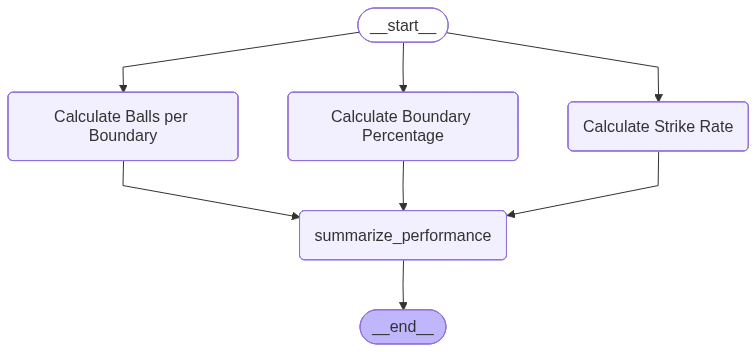

In [64]:
from IPython.display import Image

# Increase retries to 5 and delay to 2 seconds
Image(work_flow.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0))

In [65]:
initial_state = {
    "Runs": 120,
    "Balls": 80,
    "Sixes": 5,
    "Fours": 10,
}

In [67]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END

# 1. Align all keys exactly
class CricketState(TypedDict):
    Runs: int
    Balls: int
    Sixes: int
    Fours: int
    Strike_rate: float
    Balls_per_boundary: float
    Boundary_percentage: float
    Summary: str  # Added missing key

# 2. Return ONLY the update, not the whole state
def calculate_strike_rate(state: CricketState):
    strike_rate = (state["Runs"] / state["Balls"]) * 100 if state["Balls"] > 0 else 0.0
    return {"Strike_rate": strike_rate}

def calculate_balls_per_boundary(state: CricketState):
    total_boundaries = state["Sixes"] + state["Fours"]
    bpb = state["Balls"] / total_boundaries if total_boundaries > 0 else 0.0
    return {"Balls_per_boundary": bpb}

def calculate_boundary_percentage(state: CricketState):
    total_boundaries = state["Sixes"] + state["Fours"]
    b_pct = (total_boundaries / state["Balls"]) * 100 if state["Balls"] > 0 else 0.0
    return {"Boundary_percentage": b_pct}

def summarize_performance(state: CricketState):
    # Now that we fanned-in, all keys are available in the state
    summary = (
        f"Runs: {state['Runs']}, SR: {state['Strike_rate']:.2f}, "
        f"BpB: {state['Balls_per_boundary']:.2f}, "
        f"B%: {state['Boundary_percentage']:.2f}%"
    )
    return {"Summary": summary}

# 3. Build Graph
graph = StateGraph(CricketState)

graph.add_node("calc_sr", calculate_strike_rate)
graph.add_node("calc_bpb", calculate_balls_per_boundary)
graph.add_node("calc_bpct", calculate_boundary_percentage)
graph.add_node("summarize", summarize_performance)

# Fan-out
graph.add_edge(START, "calc_sr")
graph.add_edge(START, "calc_bpb")
graph.add_edge(START, "calc_bpct")

# Fan-in (LangGraph merges the separate updates into state automatically)
graph.add_edge("calc_sr", "summarize")
graph.add_edge("calc_bpb", "summarize")
graph.add_edge("calc_bpct", "summarize")

graph.add_edge("summarize", END)

work_flow = graph.compile()

In [68]:
initial_state = {
    "Runs": 120,
    "Balls": 80,
    "Sixes": 5,
    "Fours": 10,
}

In [69]:
final_state = work_flow.invoke(initial_state)
print(final_state)

{'Runs': 120, 'Balls': 80, 'Sixes': 5, 'Fours': 10, 'Strike_rate': 150.0, 'Balls_per_boundary': 5.333333333333333, 'Boundary_percentage': 18.75, 'Summary': 'Runs: 120, SR: 150.00, BpB: 5.33, B%: 18.75%'}
